# GroundedNutriRec - Notebook 02: Exploratory Data Analysis (EDA)
This notebook conducts a detailed Exploratory Data Analysis (EDA) of the Food.com dataset, covering rating distributions, user activity levels, recipe categories, and nutritional distributions. All visual figures are saved to `results/figures/`.

In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Set plotting configuration
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

# Define path parameters
recipes_path = os.path.join('..', 'data', 'raw', 'recipes.parquet')
reviews_path = os.path.join('..', 'data', 'raw', 'reviews.parquet')
figures_dir = os.path.join('..', 'results', 'figures')
os.makedirs(figures_dir, exist_ok=True)

# Load full datasets for accurate statistics
df_recipes = pd.read_parquet(recipes_path)
df_reviews = pd.read_parquet(reviews_path)
print('Data loaded successfully!')

Data loaded successfully!


## Overall Dataset Dimensions

In [2]:
total_interactions = len(df_reviews)
unique_users = df_reviews['AuthorId'].nunique()
unique_recipes = df_recipes['RecipeId'].nunique()
recipes_with_reviews = df_reviews['RecipeId'].nunique()

print(f'Total interactions: {total_interactions:,}')
print(f'Unique users: {unique_users:,}')
print(f'Unique recipes: {unique_recipes:,}')
print(f'Unique recipes with reviews: {recipes_with_reviews:,}')

Total interactions: 1,401,982
Unique users: 271,907
Unique recipes: 522,517
Unique recipes with reviews: 271,678


## Rating Distribution Analysis
We plot the distribution of user ratings to inspect user feedback skewness.

Rating Counts:
Rating
0      76248
1      16559
2      17597
3      50279
4     229217
5    1012082
Name: count, dtype: int64


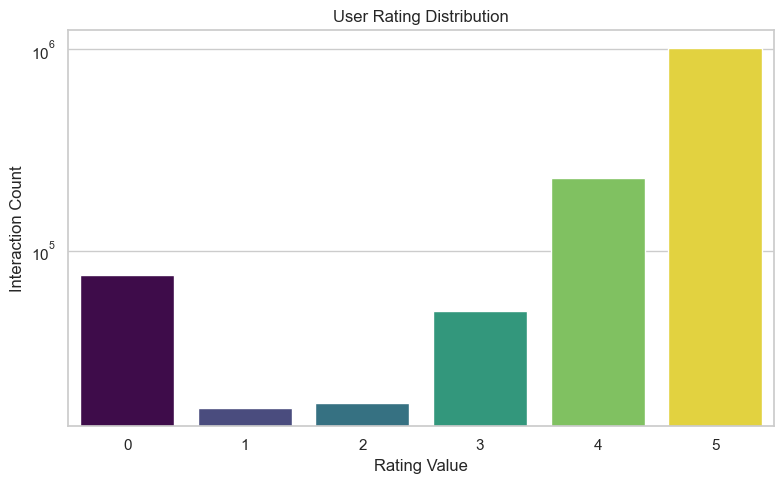

In [3]:
rating_counts = df_reviews['Rating'].value_counts().sort_index()
print('Rating Counts:')
print(rating_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, palette='viridis', hue=rating_counts.index, legend=False)
plt.title('User Rating Distribution')
plt.xlabel('Rating Value')
plt.ylabel('Interaction Count')
plt.yscale('log') # Using log scale due to high frequency of 5s
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'rating_distribution.png'), dpi=300)
plt.show()

## Top 10 Most Popular Recipes

In [4]:
top_recipes = df_reviews['RecipeId'].value_counts().head(10).reset_index()
top_recipes.columns = ['RecipeId', 'ReviewCount']
top_recipes_merged = pd.merge(top_recipes, df_recipes[['RecipeId', 'Name', 'RecipeCategory']], on='RecipeId')
display(top_recipes_merged)

,RecipeId,ReviewCount,Name,RecipeCategory
0,45809,2892,Bourbon Chicken,Chicken Breast
1,2886,2182,Best Banana Bread,Quick Breads
2,27208,1614,To Die for Crock Pot Roast,One Dish Meal
3,89204,1584,Crock-Pot Chicken With Black Beans &amp; Cream...,One Dish Meal
4,39087,1491,Creamy Cajun Chicken Pasta,Chicken Breast
5,67256,1359,Best Ever Banana Cake With Cream Cheese Frosting,Dessert
6,35813,1353,Oatmeal Raisin Cookies,Drop Cookies
7,54257,1325,"Yes, Virginia There is a Great Meatloaf",Meatloaf
8,22782,1273,Jo Mama's World Famous Spaghetti,Spaghetti
9,32204,1228,&quot;Whatever Floats Your Boat&quot; Brownies!,Bar Cookie


## Missing Value Analysis

In [5]:
print('Recipes Missing Values:')
print(df_recipes.isnull().sum()[df_recipes.isnull().sum() > 0])

print('\nReviews Missing Values:')
print(df_reviews.isnull().sum()[df_reviews.isnull().sum() > 0])

Recipes Missing Values:
CookTime             82545
Description              5
Images                   1
RecipeCategory         751
AggregatedRating    253223
ReviewCount         247489
RecipeServings      182911
RecipeYield         348071
dtype: int64

Reviews Missing Values:
Series([], dtype: int64)


## Recipe Category Distribution

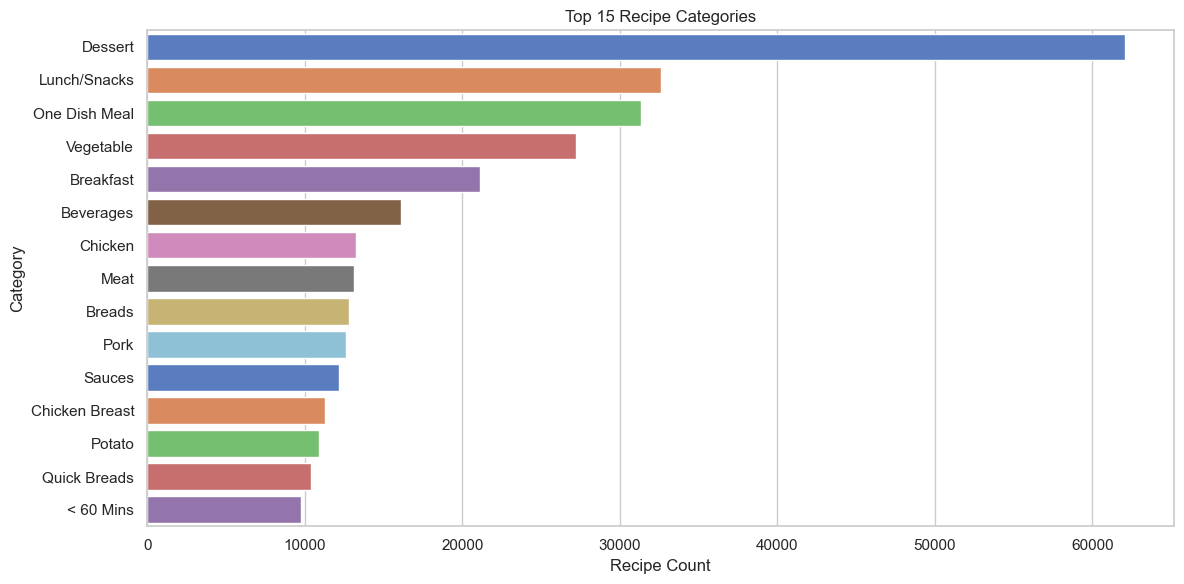

In [6]:
top_categories = df_recipes['RecipeCategory'].value_counts().head(15)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_categories.values, y=top_categories.index, palette='muted', hue=top_categories.index, legend=False)
plt.title('Top 15 Recipe Categories')
plt.xlabel('Recipe Count')
plt.ylabel('Category')
plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'category_distribution.png'), dpi=300)
plt.show()

## Nutritional Distribution Analysis
For health-aware food recommendation, analyzing macro and micronutrients is crucial. Here we verify and plot the distributions of Calories, Protein, Fats, and Carbs.

,Calories,ProteinContent,FatContent,CarbohydrateContent
count,522517.000000,522517.000000,522517.000000,522517.000000
mean,484.438580,17.469510,24.614922,49.089092
std,1397.116649,40.128837,111.485798,180.822062
min,0.000000,0.000000,0.000000,0.000000
25%,174.200000,3.500000,5.600000,12.800000
50%,317.100000,9.100000,13.800000,28.200000
75%,529.100000,25.000000,27.400000,51.100000
max,612854.600000,18396.200000,64368.100000,108294.600000


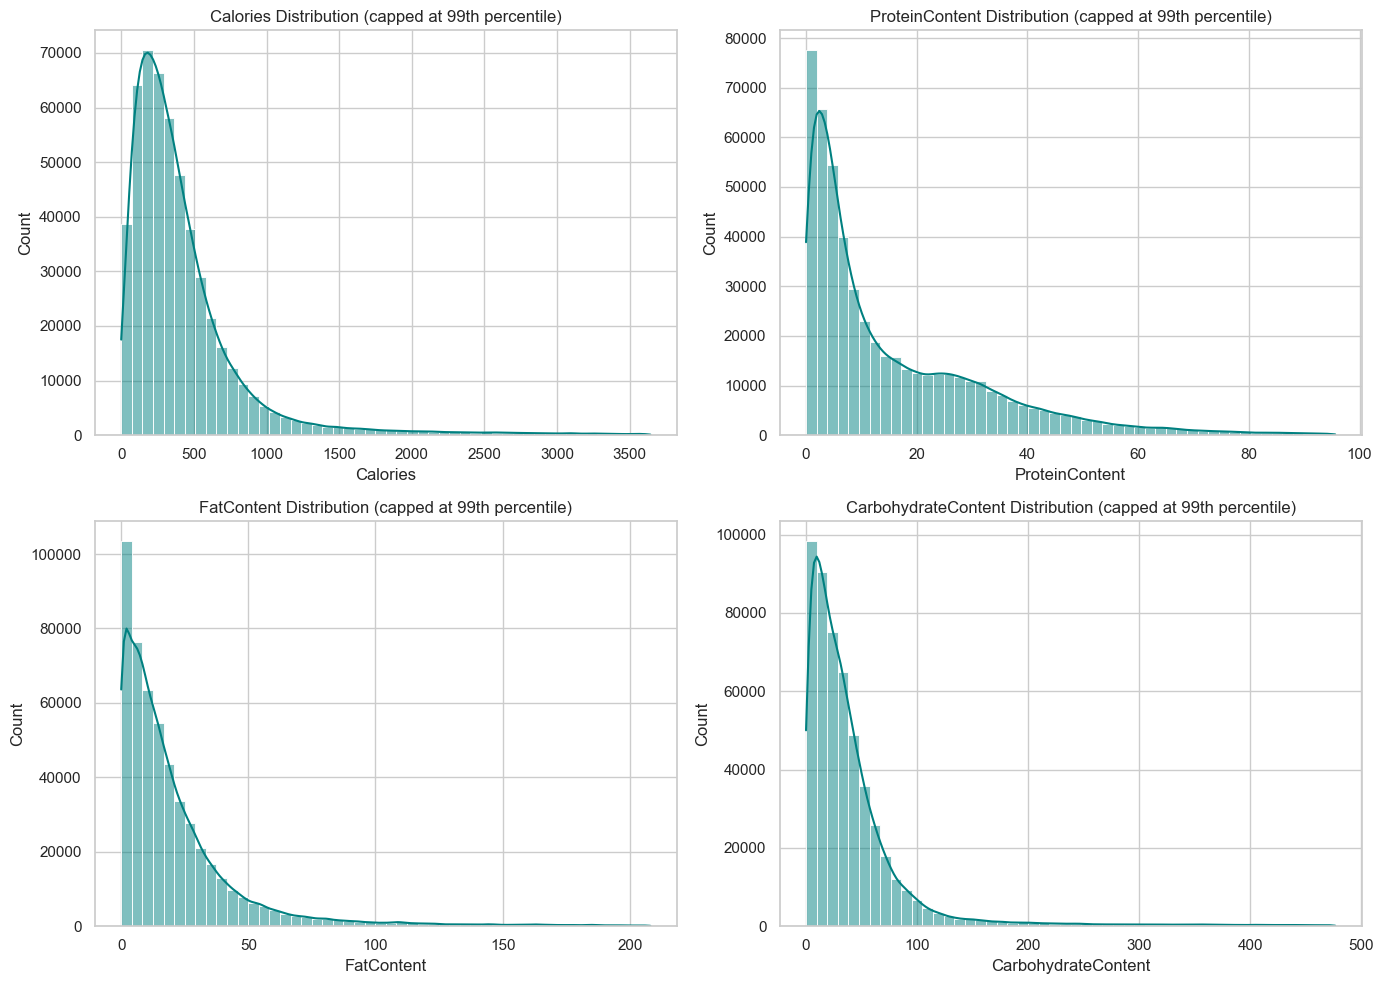

In [7]:
nutrients = ['Calories', 'ProteinContent', 'FatContent', 'CarbohydrateContent']
display(df_recipes[nutrients].describe())

# Plot distributions
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, nutr in enumerate(nutrients):
    # Cap outliers at 99th percentile for visualization clarity
    cap = df_recipes[nutr].quantile(0.99)
    sns.histplot(df_recipes[df_recipes[nutr] <= cap][nutr], bins=50, kde=True, ax=axes[i], color='teal')
    axes[i].set_title(f'{nutr} Distribution (capped at 99th percentile)')
    axes[i].set_xlabel(nutr)
    axes[i].set_ylabel('Count')

plt.tight_layout()
plt.savefig(os.path.join(figures_dir, 'nutrition_distribution.png'), dpi=300)
plt.show()

## Preparation and Cook Time Analysis

In [8]:
# Check CookTime and PrepTime values
print(df_recipes[['PrepTime', 'CookTime', 'TotalTime']].head(5))

  PrepTime CookTime TotalTime
0    PT45M    PT24H  PT24H45M
1     PT4H    PT25M   PT4H25M
2    PT30M     PT5M     PT35M
3    PT24H    PT20M  PT24H20M
4    PT20M    PT30M     PT50M
